# Lab 5
## neural networks


### Initialization

In [1]:
import pandas as pd

data = pd.read_csv(r'binary_classification_moons.csv')
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [2]:
data.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


### Feature Design

#### Algorithm Selection

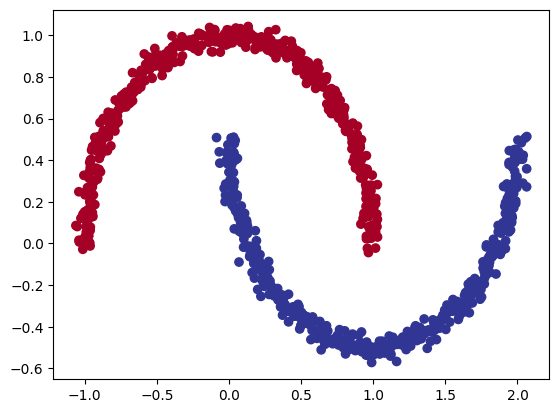

In [3]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=data.X1, 
            y=data.X2, 
            c=data.label, 
            cmap=plt.cm.RdYlBu
            );

In [4]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [5]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [6]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

C:\Users\SHARMA\AppData\Local\Temp\ipykernel_8084\3536051194.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [8]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [9]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [10]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)
    
    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [11]:
model = model_0

In [12]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.2350],
        [0.0874],
        [0.2447],
        [0.0665],
        [0.1863],
        [0.1653],
        [0.1431],
        [0.1683],
        [0.2597],
        [0.0910]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### Loss Function Selection

In [13]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

In [14]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[0.2350],
        [0.0874],
        [0.2447],
        [0.0665],
        [0.1863]], grad_fn=<SliceBackward0>)

In [15]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5585],
        [0.5218],
        [0.5609],
        [0.5166],
        [0.5464]], grad_fn=<SigmoidBackward0>)

In [16]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.], grad_fn=<SqueezeBackward0>)

In [17]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Model Learning

In [18]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device) 

### Model Evaluation

In [24]:
from utils_py import train_and_test_loop

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

Epoch: 0 | Loss: 0.67039, Accuracy: 50.00% | Test loss: 0.66257, Test acc: 50.00%
Epoch: 10 | Loss: 0.58914, Accuracy: 83.88% | Test loss: 0.58945, Test acc: 82.00%
Epoch: 20 | Loss: 0.51487, Accuracy: 81.75% | Test loss: 0.52220, Test acc: 81.50%
Epoch: 30 | Loss: 0.45188, Accuracy: 82.12% | Test loss: 0.46537, Test acc: 81.00%
Epoch: 40 | Loss: 0.40463, Accuracy: 82.25% | Test loss: 0.42250, Test acc: 81.00%
Epoch: 50 | Loss: 0.37161, Accuracy: 82.88% | Test loss: 0.39183, Test acc: 81.50%
Epoch: 60 | Loss: 0.34861, Accuracy: 83.12% | Test loss: 0.36964, Test acc: 81.50%
Epoch: 70 | Loss: 0.33201, Accuracy: 83.38% | Test loss: 0.35286, Test acc: 81.50%
Epoch: 80 | Loss: 0.31940, Accuracy: 83.88% | Test loss: 0.33951, Test acc: 82.00%
Epoch: 90 | Loss: 0.30935, Accuracy: 84.38% | Test loss: 0.32842, Test acc: 82.50%


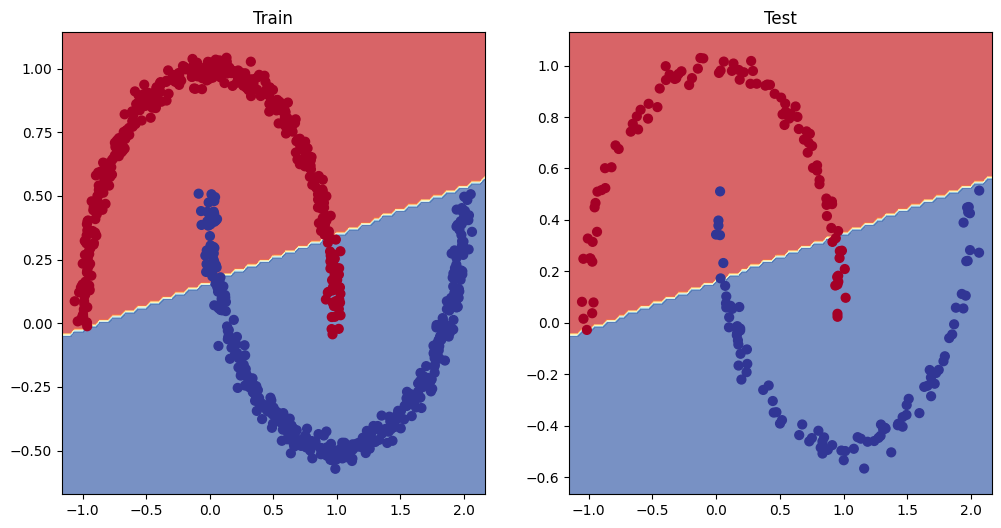

In [231]:
from utils import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [28]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

### Improving The Model

In [ ]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return (self.layer_3(self.layer_2(self.layer_1(x))))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [30]:
model = model_1
epochs = 1000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.70134, Test acc: 45.50%
Epoch: 10 | Loss: 0.58674, Accuracy: 79.62% | Test loss: 0.58552, Test acc: 78.00%
Epoch: 20 | Loss: 0.47594, Accuracy: 79.62% | Test loss: 0.48700, Test acc: 77.00%
Epoch: 30 | Loss: 0.39832, Accuracy: 81.00% | Test loss: 0.41841, Test acc: 77.00%
Epoch: 40 | Loss: 0.35499, Accuracy: 81.62% | Test loss: 0.37773, Test acc: 78.00%
Epoch: 50 | Loss: 0.32886, Accuracy: 82.62% | Test loss: 0.35055, Test acc: 80.50%
Epoch: 60 | Loss: 0.31010, Accuracy: 83.75% | Test loss: 0.32940, Test acc: 82.00%
Epoch: 70 | Loss: 0.29513, Accuracy: 84.75% | Test loss: 0.31171, Test acc: 83.50%
Epoch: 80 | Loss: 0.28276, Accuracy: 85.00% | Test loss: 0.29670, Test acc: 85.50%
Epoch: 90 | Loss: 0.27260, Accuracy: 85.62% | Test loss: 0.28413, Test acc: 86.50%
Epoch: 100 | Loss: 0.26443, Accuracy: 86.25% | Test loss: 0.27384, Test acc: 87.50%
Epoch: 110 | Loss: 0.25803, Accuracy: 87.00% | Test loss: 0.26561, Test acc: 87.50%
Epo

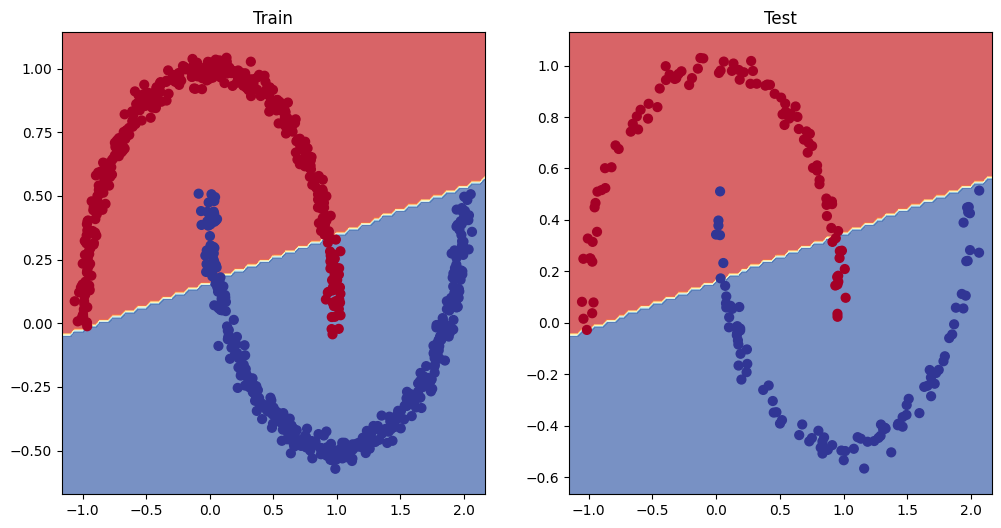

In [31]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

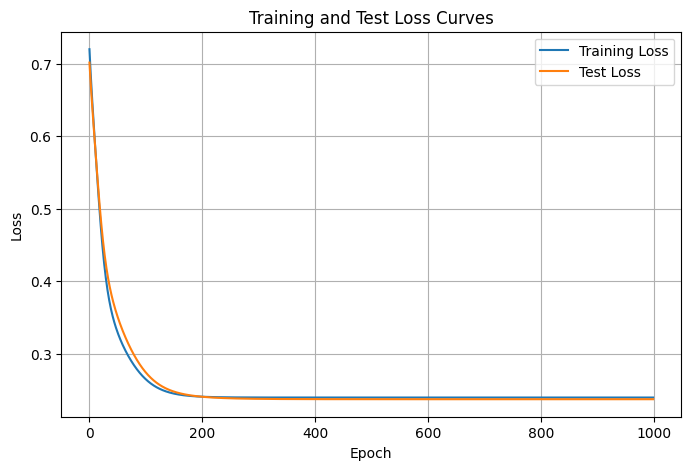

In [32]:
plot_loss_curves(train_losses, test_losses)

### Improving model(task2)

In [38]:
class ModelVtask(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=8)
        self.layer_3 = nn.Linear(in_features=8, out_features=6)
        self.layer_4 = nn.Linear(in_features=6, out_features=4)
        self.layer_5 = nn.Linear(in_features=4, out_features=6)
        self.layer_6 = nn.Linear(in_features=6, out_features=1)
        
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_6(self.layer_5(self.layer_4(self.layer_3(self.layer_2(self.layer_1(x))))))

model_1 = ModelVtask().to(device)
model_1

ModelVtask(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=8, bias=True)
  (layer_3): Linear(in_features=8, out_features=6, bias=True)
  (layer_4): Linear(in_features=6, out_features=4, bias=True)
  (layer_5): Linear(in_features=4, out_features=6, bias=True)
  (layer_6): Linear(in_features=6, out_features=1, bias=True)
)

In [39]:
model = model_1
epochs = 1800

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.71257, Accuracy: 50.00% | Test loss: 0.70597, Test acc: 50.00%
Epoch: 10 | Loss: 0.66510, Accuracy: 77.62% | Test loss: 0.66172, Test acc: 84.00%
Epoch: 20 | Loss: 0.59104, Accuracy: 82.38% | Test loss: 0.58799, Test acc: 82.50%
Epoch: 30 | Loss: 0.43690, Accuracy: 82.12% | Test loss: 0.44311, Test acc: 82.00%
Epoch: 40 | Loss: 0.32361, Accuracy: 82.75% | Test loss: 0.34442, Test acc: 83.00%
Epoch: 50 | Loss: 0.29191, Accuracy: 83.75% | Test loss: 0.30931, Test acc: 83.50%
Epoch: 60 | Loss: 0.27610, Accuracy: 85.12% | Test loss: 0.28859, Test acc: 85.50%
Epoch: 70 | Loss: 0.26383, Accuracy: 86.00% | Test loss: 0.27242, Test acc: 87.00%
Epoch: 80 | Loss: 0.25425, Accuracy: 87.12% | Test loss: 0.25975, Test acc: 87.50%
Epoch: 90 | Loss: 0.24750, Accuracy: 87.62% | Test loss: 0.25062, Test acc: 88.50%
Epoch: 100 | Loss: 0.24337, Accuracy: 88.12% | Test loss: 0.24471, Test acc: 88.50%
Epoch: 110 | Loss: 0.24117, Accuracy: 88.50% | Test loss: 0.24126, Test acc: 89.50%
Epo

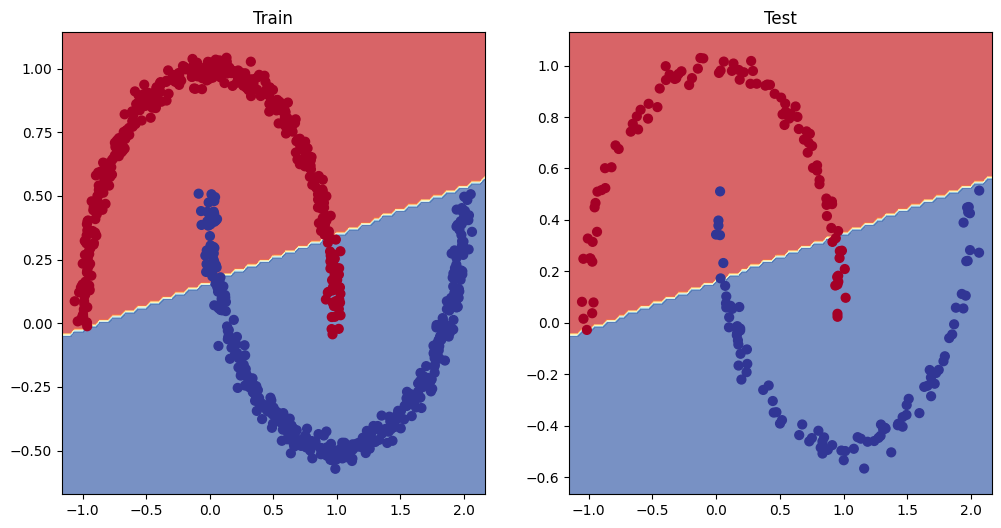

In [40]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

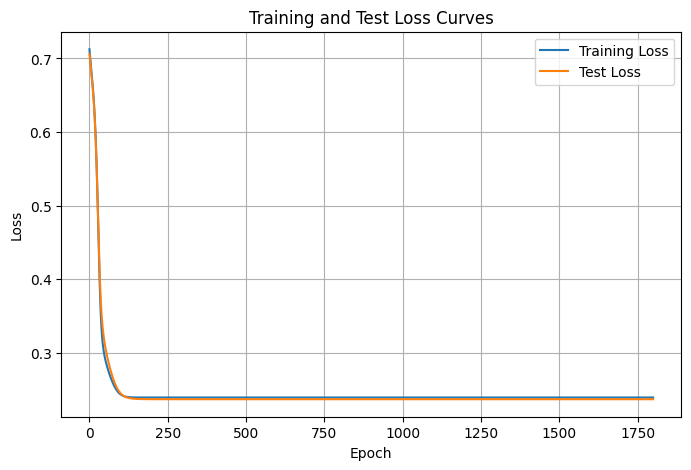

In [41]:
plot_loss_curves(train_losses, test_losses)

### Task 3

In [ ]:
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_2 = ModelV2().to(device)
model_2
    

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [55]:
model=model_2

In [57]:

epochs = 1800

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.70382, Accuracy: 20.75% | Test loss: 0.70248, Test acc: 27.00%
Epoch: 10 | Loss: 0.69961, Accuracy: 30.12% | Test loss: 0.69907, Test acc: 36.00%
Epoch: 20 | Loss: 0.69585, Accuracy: 50.00% | Test loss: 0.69577, Test acc: 50.00%
Epoch: 30 | Loss: 0.69308, Accuracy: 48.12% | Test loss: 0.69352, Test acc: 47.50%
Epoch: 40 | Loss: 0.69185, Accuracy: 37.25% | Test loss: 0.69243, Test acc: 30.00%
Epoch: 50 | Loss: 0.69079, Accuracy: 36.25% | Test loss: 0.69146, Test acc: 34.00%
Epoch: 60 | Loss: 0.68964, Accuracy: 43.88% | Test loss: 0.69041, Test acc: 42.50%
Epoch: 70 | Loss: 0.68831, Accuracy: 50.12% | Test loss: 0.68921, Test acc: 48.00%
Epoch: 80 | Loss: 0.68669, Accuracy: 54.12% | Test loss: 0.68775, Test acc: 49.50%
Epoch: 90 | Loss: 0.68463, Accuracy: 57.63% | Test loss: 0.68589, Test acc: 52.50%
Epoch: 100 | Loss: 0.68194, Accuracy: 59.75% | Test loss: 0.68345, Test acc: 54.50%
Epoch: 110 | Loss: 0.67832, Accuracy: 65.75% | Test loss: 0.68016, Test acc: 62.50%
Epo

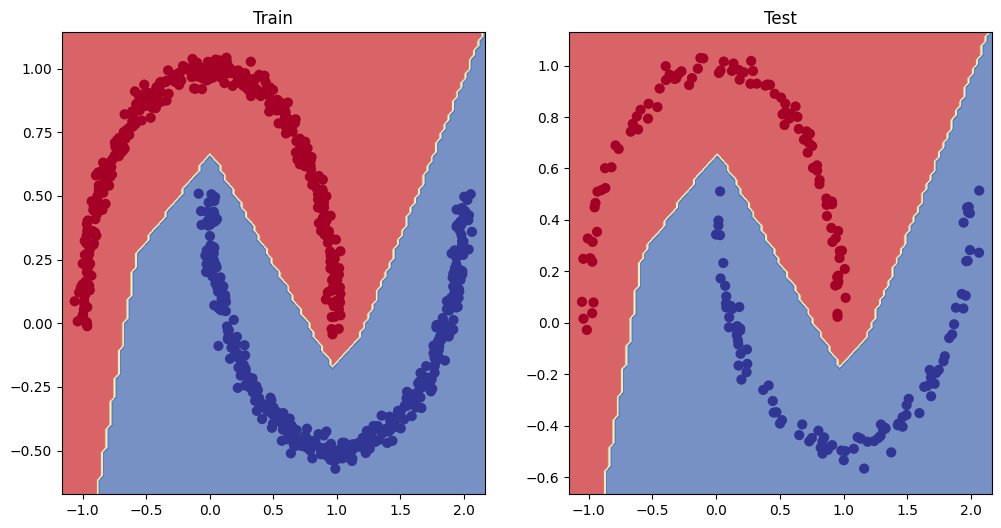

In [58]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

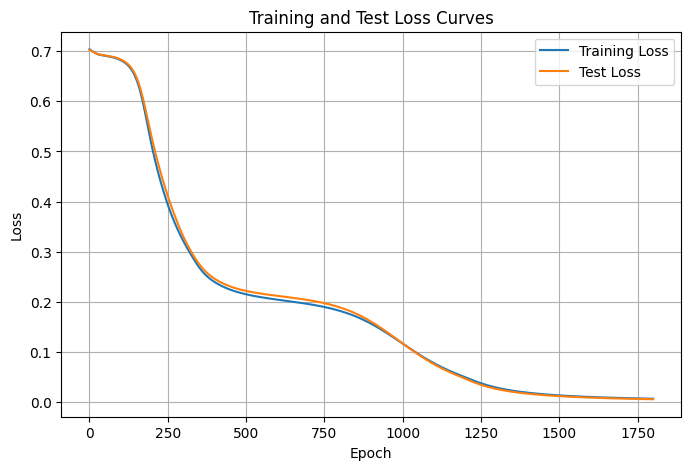

In [59]:
plot_loss_curves(train_losses, test_losses)

## Discussion and Conclusion

This lab built three neural network models in PyTorch to classify the moons dataset which is a non-linearly separable binary problem. ModelV0, ModelV1, and ModelVtask all lacked activation functions,producing linear decision boundaries that failed to capture the curved structure regardless of depth or training epochs. ModelV2 introduced ReLU activation, enabling the network to learn a non-linear boundary and correctly classify both classes.

The key takeaway is that depth alone cannot compensate for the absence of non-linear activations.Only ModelV2, with ReLU, successfully learned the moons decision boundary,confirming that activation function selection is fundamental to solving non-linear classification tasks.